Testing of Linear Regression starts on Cell 16. Below are the preprocessing steps as per Week 3.

In [1]:
import numpy as np
import pandas as pd
import glob

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


files = glob.glob('/home/jorge/Documents/IDX/datasets/*.csv')
df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)

rows_before_type_filter = len(df)
df = df[(df['PropertyType'] == 'Residential') & (df['PropertySubType'] == 'SingleFamilyResidence')]
print(df.shape)

rows_removed = rows_before_type_filter - len(df)
print(f"Removed {rows_removed:,} rows ({rows_removed / rows_before_type_filter:.1%}) that were not Residential/SingleFamilyResidence")

(141997, 78)
Removed 139,826 rows (49.6%) that were not Residential/SingleFamilyResidence


Making sure to filter for the features that we are interested in, not the final list of features. And then check how many are null in each column of interest.

In [2]:
cols_of_interest = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
                    'LotSizeSquareFeet', 'YearBuilt', 'CloseDate', 'Latitude', 'Longitude',
                   'CountyOrParish', 'AssociationFee', 'Stories',
                   'FireplaceYN', 'NewConstructionYN', 'AttachedGarageYN', 'ViewYN', 'PoolPrivateYN']

print("Number of Null Rows in each column of interest \n")
print(df[cols_of_interest].isnull().sum())

Number of Null Rows in each column of interest 

ClosePrice                   0
LivingArea                  78
BedroomsTotal                0
BathroomsTotalInteger       13
LotSizeSquareFeet         2433
YearBuilt                   97
CloseDate                    0
Latitude                    13
Longitude                   13
CountyOrParish               0
AssociationFee           41364
Stories                  14774
FireplaceYN                108
NewConstructionYN        10830
AttachedGarageYN         17195
ViewYN                   12901
PoolPrivateYN            10978
dtype: int64


Chose to drop rows with missing LivingArea, Bathrooms, Latitude, Longitude because:
1. Living Area and Square Footage vary most by location, and has a relatively low number of missing values, making imputing this data not worthwhile
2. Bathrooms also has relatively low number of missing values
3. Latitude and Longitude are needed for Geographical features, also have relatively low number of missing values

Chose to impute null YearBuilt values with median because as shown on histogram below, they tend to fall within the range of 1950 - 1975, peaking at around 1960.

**Leakage fix:** compute the median from train rows only (CloseDate < 2026-05-01) instead of the full df, so the test set's YearBuilt/Stories values never influence the imputed value.

Chose to impute AssociationFee with 0, since no data assumes no Association Fee.

Impute Stories with median, since empty doesn't imply no stories.

Impute boolean features with False - absence of data assumes feature not present.

In [3]:
rows_before_dropna = len(df)
df = df.dropna(subset=['LivingArea', 'BathroomsTotalInteger', 'Latitude', 'Longitude', 'LotSizeSquareFeet'])

train_mask = pd.to_datetime(df['CloseDate']) < '2026-05-01'

yearbuilt_median = df.loc[train_mask, 'YearBuilt'].median()
print(yearbuilt_median)

df['YearBuilt'] = df['YearBuilt'].fillna(yearbuilt_median)

df['AssociationFee'] = df['AssociationFee'].fillna(0)

stories_median = df.loc[train_mask, 'Stories'].median()
df['Stories'] = df['Stories'].fillna(stories_median)

for col in ['FireplaceYN', 'NewConstructionYN', 'AttachedGarageYN', 'ViewYN', 'PoolPrivateYN']:
    df[col] = df[col].fillna(False)

1976.0


In [4]:
print("After cleaning:")
print(df[cols_of_interest].isnull().sum())
print(df.shape)

rows_removed = rows_before_dropna - len(df)
print(f"Removed {rows_removed:,} rows ({rows_removed / rows_before_dropna:.1%}) with missing LivingArea/Bathrooms/Latitude/Longitude/LotSize")

After cleaning:
ClosePrice               0
LivingArea               0
BedroomsTotal            0
BathroomsTotalInteger    0
LotSizeSquareFeet        0
YearBuilt                0
CloseDate                0
Latitude                 0
Longitude                0
CountyOrParish           0
AssociationFee           0
Stories                  0
FireplaceYN              0
NewConstructionYN        0
AttachedGarageYN         0
ViewYN                   0
PoolPrivateYN            0
dtype: int64
(139461, 78)
Removed 2,536 rows (1.8%) with missing LivingArea/Bathrooms/Latitude/Longitude/LotSize


Histogram in question to show how homes generally fall within said range of 1950-1970.

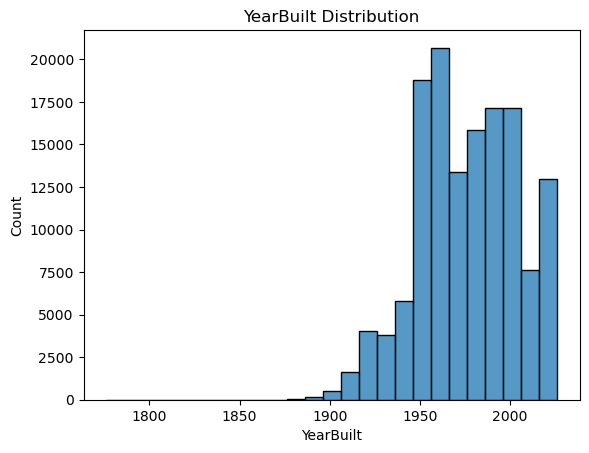

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['YearBuilt'].dropna(), bins=25)
plt.title('YearBuilt Distribution')
plt.show()

Before moving on, I want to remove the clear extreme outlier in the Glennville Area, `$900m` home. This is to prevent issues further on when using the model, since the difference in medians between the first 2 MLSAreas is `$880m`. Median prices in Malibu, the 2nd highest in the MLSAreas behind Glennville, is `$12m`. To still retain legitimate data, I will limit analysis to homes with prices over 50k and under `$15m`.

I ran into an issue because I had this cell after the test/train split, and once I wanted to use the log transform near the bottom of the notebook, I got errors that a 0 value slipped through. The bug has been fixed - R^2 score jumped from 0.3 to 0.6 after fixing this bug, without log transform.

**Best practice fix:** outlier thresholds must be learned from training data alone. Compute the 0.5th/99.5th percentile of ClosePrice using train rows only, then apply those frozen cutoffs to the whole dataset (both train and test) - never recompute percentiles on test data.

In [6]:
train_mask = pd.to_datetime(df['CloseDate']) < '2026-05-01'

closeprice_low = df.loc[train_mask, 'ClosePrice'].quantile(0.005)
closeprice_high = df.loc[train_mask, 'ClosePrice'].quantile(0.995)
print(f"Train-only ClosePrice bounds: ${closeprice_low:,.0f} - ${closeprice_high:,.0f}")

rows_before_price_filter = len(df)
df = df[(df['ClosePrice'] >= closeprice_low) & (df['ClosePrice'] <= closeprice_high)]

rows_removed = rows_before_price_filter - len(df)
print(f"Removed {rows_removed:,} rows ({rows_removed / rows_before_price_filter:.1%}) outside the train-only ClosePrice bounds")

Train-only ClosePrice bounds: $185,000 - $8,915,100
Removed 1,359 rows (1.0%) outside the train-only ClosePrice bounds


Setting test/train splits for the model.

In [7]:
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

test = df[df['CloseDate'] >= '2026-05-01']
train = df[df['CloseDate'] < '2026-05-01']

print(train.shape)
print(test.shape)

(126399, 78)
(11703, 78)


Additionally checking County or Parish.

In [8]:
print(df.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending=False).head(20))
print(df['CountyOrParish'].nunique())

CountyOrParish
San Mateo          2050000.0
Mono               1910000.0
Santa Clara        1900000.0
Orange             1400000.0
Santa Cruz         1350000.0
San Francisco      1335000.0
Alameda            1300000.0
Marin              1287500.0
San Diego          1059000.0
Los Angeles        1008000.0
Ventura             970000.0
Monterey            958000.0
San Luis Obispo     935000.0
Contra Costa        899000.0
Napa                880000.0
Sonoma              790000.0
San Benito          780000.0
Santa Barbara       759000.0
El Dorado           725000.0
Placer              668750.0
Name: ClosePrice, dtype: float64
60


CountyOrParish has 60 which is more manageable for encoding, hence why I chose it over the other location metrics.

In [9]:
numerical_features = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
                      'LotSizeSquareFeet', 'YearBuilt', 'Latitude', 'Longitude',
                      'AssociationFee', 'Stories']

boolean_features = ['FireplaceYN', 'NewConstructionYN', 'AttachedGarageYN',
                    'ViewYN', 'PoolPrivateYN']

categorical_features = ['CountyOrParish']
target = 'ClosePrice'

features = numerical_features + boolean_features + categorical_features

Here, I am doing some additional checking for extreme outliers to filter out. Brought to my attention by my groupmates in DS55.

In [10]:
numeric_cols = numerical_features
print(df[numeric_cols].describe())

          LivingArea  BedroomsTotal  BathroomsTotalInteger  LotSizeSquareFeet  \
count  138102.000000  138102.000000          138102.000000       1.381020e+05   
mean     2029.306374       3.489189               2.614618       3.735806e+05   
std       948.084337       0.948090               1.074691       1.753918e+07   
min         0.000000       0.000000               0.000000       0.000000e+00   
25%      1389.000000       3.000000               2.000000       5.663000e+03   
50%      1819.000000       3.000000               2.000000       7.265000e+03   
75%      2434.000000       4.000000               3.000000       1.042500e+04   
max     17153.000000      22.000000              35.000000       1.938943e+09   

           YearBuilt       Latitude      Longitude  AssociationFee  \
count  138102.000000  138102.000000  138102.000000   138102.000000   
mean     1975.773218      34.760488    -118.625262       72.771528   
std        27.572231       1.751073       3.225167      267.

Latitude and Longitude bounds for California (inspired by Kelvin).

LivingArea must be positive non-zero number to be seriously considered.

Reasonable caps for both bedrooms and bathrooms, captures legit values while removing extreme outliers.

LotSize cap of 10 acres = 435,600 sqft, reasonable bound accounts for large lots and filters bad data.

**Leakage fix:** the block above only ever reassigns `df`, but `train`/`test` were already sliced off as separate DataFrames earlier (test/train split cell), so these bounds never actually reached the modeling data. Applying the same fixed bounds directly to train/test here so the outliers are actually removed from what the model trains/evaluates on.

In [11]:
df = df[
    (df['Latitude'] >= 32.5) & (df['Latitude'] <= 42.5) &
    (df['Longitude'] >= -124.5) & (df['Longitude'] <= -114.5)
]

df = df[df['LivingArea'] > 0]

df = df[(df['BedroomsTotal'] <= 15) & (df['BathroomsTotalInteger'] <= 15)]

df = df[df['LotSizeSquareFeet'] <= 435600]

train_before = len(train)
test_before = len(test)

train = train[
    (train['Latitude'] >= 32.5) & (train['Latitude'] <= 42.5) &
    (train['Longitude'] >= -124.5) & (train['Longitude'] <= -114.5)
]
test = test[
    (test['Latitude'] >= 32.5) & (test['Latitude'] <= 42.5) &
    (test['Longitude'] >= -124.5) & (test['Longitude'] <= -114.5)
]

train = train[train['LivingArea'] > 0]
test = test[test['LivingArea'] > 0]

train = train[(train['BedroomsTotal'] <= 15) & (train['BathroomsTotalInteger'] <= 15)]
test = test[(test['BedroomsTotal'] <= 15) & (test['BathroomsTotalInteger'] <= 15)]

train = train[train['LotSizeSquareFeet'] <= 435600]
test = test[test['LotSizeSquareFeet'] <= 435600]

print(train.shape)
print(test.shape)

train_removed = train_before - len(train)
test_removed = test_before - len(test)
print(f"Removed {train_removed:,} train rows ({train_removed / train_before:.1%}) and {test_removed:,} test rows ({test_removed / test_before:.1%}) as lat/long/size outliers")

(125549, 78)
(11631, 78)
Removed 850 train rows (0.7%) and 72 test rows (0.6%) as lat/long/size outliers


After fully filtering for bad values, we have around 139000 points of data to analyse.

After filtering, 97% of rows remain, good retention.

In [12]:
print(df[numerical_features + ['ClosePrice']].describe())

          LivingArea  BedroomsTotal  BathroomsTotalInteger  LotSizeSquareFeet  \
count  137180.000000  137180.000000          137180.000000      137180.000000   
mean     2026.275506       3.488781               2.611175       14801.918150   
std       940.119139       0.941404               1.061523       33578.007549   
min       100.000000       0.000000               0.000000           0.000000   
25%      1388.000000       3.000000               2.000000        5663.000000   
50%      1817.000000       3.000000               2.000000        7242.000000   
75%      2431.000000       4.000000               3.000000       10265.250000   
max     17153.000000      15.000000              15.000000      435600.000000   

           YearBuilt       Latitude      Longitude  AssociationFee  \
count  137180.000000  137180.000000  137180.000000   137180.000000   
mean     1975.715053      34.760149    -118.660071       72.468595   
std        27.571574       1.686036       1.844744      265.

In [13]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

Get cleaned data and preprocess it, by encoding categorical features and scaling numerical values.

In [14]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features + boolean_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(125549, 73)
(11631, 73)


In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_processed, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](73,)","[ 521177.89, -135130.15, 235842.14,...,-1737015.56, 280263.03, 677147.75]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.387e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,73


In [16]:
feature_names = numerical_features + boolean_features + categorical_features
for name, coef in zip(feature_names, model.coef_[:len(numerical_features + boolean_features)]):
    print(f"{name}: {coef:.2f}")

LivingArea: 521177.89
BedroomsTotal: -135130.15
BathroomsTotalInteger: 235842.14
LotSizeSquareFeet: -22944.01
YearBuilt: -103129.49
Latitude: -1247779.45
Longitude: -610476.35
AssociationFee: 50029.00
Stories: -91160.57
FireplaceYN: 24468.54
NewConstructionYN: 29220.73
AttachedGarageYN: -33722.85
ViewYN: 41482.12
PoolPrivateYN: 11938.14


Strange how Bedrooms, Year, Stories, Pools, Fireplaces have negative coefficients.

**Baseline R² score = 0.6342**

In [17]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

y_pred = model.predict(X_test_processed)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test))

print(f"R² Score: {r2:.4f}")
print(f"MAE: ${mae:,.0f}")
print(f"MAPE: {mape:.2%}")
print(f"MdAPE: {mdape:.2%}")

R² Score: 0.6338
MAE: $375,917
MAPE: 34.95%
MdAPE: 25.94%


My teammates mentioned log transform, so I wanted to try it out since ClosePrice is skewed right. [Question]: Would it be possible to use log transform on other features that are skewed right? worth considering. NOT BASELINE R^2 SCORE, but R^2 here = 0.7635, a clear increase compared to Baseline score.

**Note:** predictions are back-transformed to dollar scale so MAE/MAPE/MdAPE reflect real price error, not log-price error - MAPE/MdAPE/MAE should be comparable directly against the baseline model.

In [18]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

model_log = LinearRegression()
model_log.fit(X_train_processed, y_train_log)

y_pred_log = model_log.predict(X_test_processed)
r2_log = r2_score(y_test_log, y_pred_log)
print(f"Log-transformed R²: {r2_log:.4f}")

y_pred_dollars = np.exp(y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_dollars)
mape_log = mean_absolute_percentage_error(y_test, y_pred_dollars)
mdape_log = np.median(np.abs((y_test - y_pred_dollars) / y_test))

print(f"MAE (back-transformed): ${mae_log:,.0f}")
print(f"MAPE (back-transformed): {mape_log:.2%}")
print(f"MdAPE (back-transformed): {mdape_log:.2%}")

Log-transformed R²: 0.7622
MAE (back-transformed): $337,238
MAPE (back-transformed): 23.53%
MdAPE (back-transformed): 18.05%
